## PDF for mean-based methods

In this notebook, I plot the histogram of n=1000 noise realizations and compare it with the theoretical PDF for mean-based method.

In [1]:
import os as os
import sys
import numpy as np

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

# adding folders to sys.path
project_root = os.path.abspath(os.path.join(os.getcwd()  , '..', '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

akshat_lisa_root = os.path.abspath(os.path.join(os.getcwd()  , '..',))
if akshat_lisa_root not in sys.path:
    sys.path.insert(0, akshat_lisa_root)

from scripts.readTdi import readTdi, getTdiPath
from psd_estimation_methods.wosa import wosa
from scripts.psdNoise import n_time_noise_from_psd, n_noise_psds, compute_psd_noise_distribution, normalized_psd_residual
from scripts.plot import plot_psd_noise_histogram, plot, plot_orig_and_noise_psds, plot_psd_noise_histogram_two_cross_two, draw_chi2
import scipy

Read TDI data, and draw the TDI plot and its PSD:

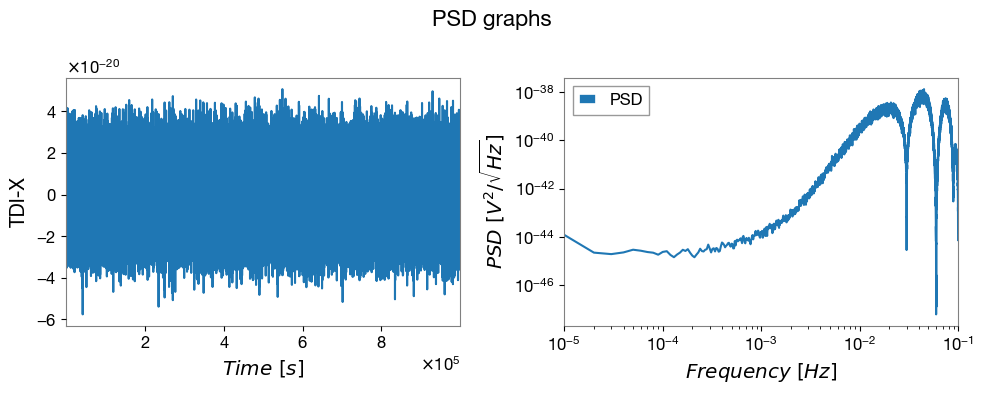

In [2]:
# 1) Read the TDI time series
tdi_path = getTdiPath('vsmall_glitch_long_tdi.h5')
data_orig, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 20000
f_orig, orig_psd, _, nseg = wosa(
    x=data_orig,
    fs=fs,
    nperseg=nperseg
) 

f_orig, orig_psd = scipy.signal.welch(
    x=data_orig,
    fs=fs,
    nperseg=nperseg
) 

plot(
    data=data_orig,
    t=t, 
    f=f_orig, 
    psd= [orig_psd],
    labels= ["PSD"],
    title="TDI-X", 
    bigtitle="PSD graphs",
    f_lims = [f_orig[1], (fs / 2.0)]
)

# 3) generate n time-domain noise realisations such that PSD equals "PSD OF TDI time series "
time_noises = n_time_noise_from_psd(
    orig_psd, 
    fs, 
    nperseg, 
    n=1000,
    seed_offset=0
)

Generate n=1000 noise realisations from the time series such that on average, the PSD of the noise realisation matches that of the original time series

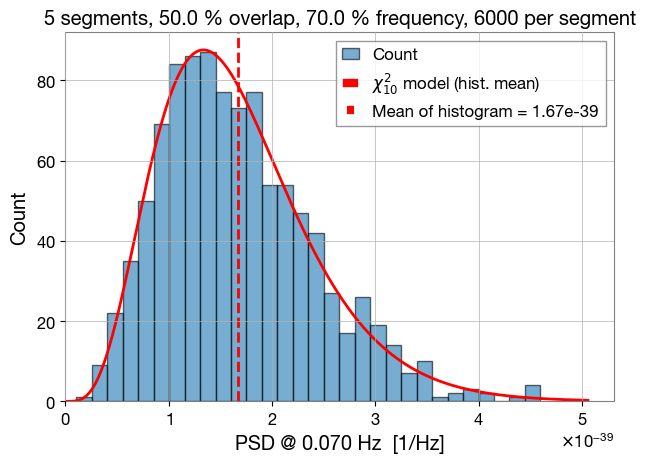

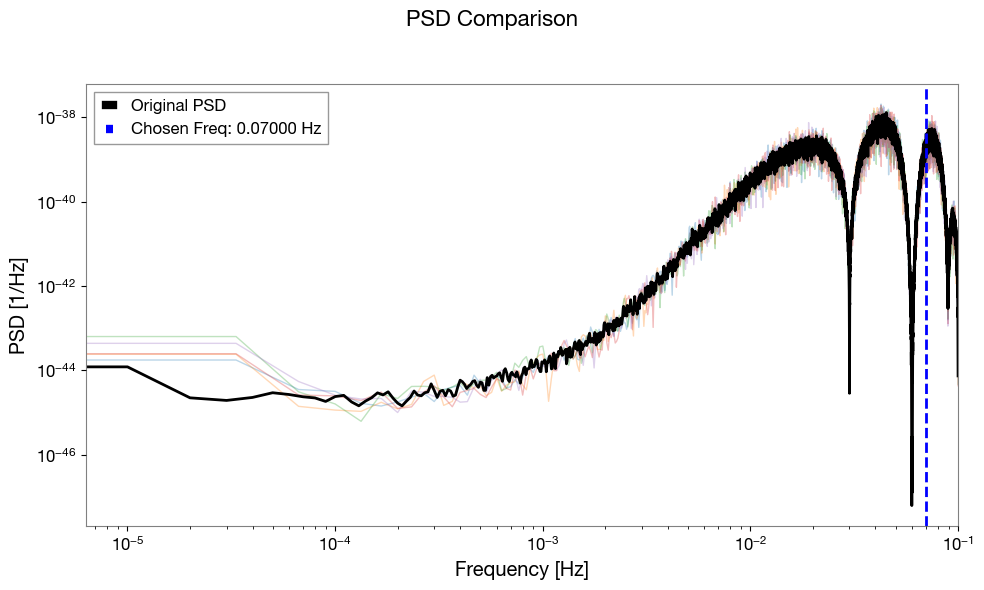

In [22]:
# 4) Find PSDs of time-domain noise realisations
nperseg_noise = 6000
noverlap= nperseg_noise // 2
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap= noverlap)

# 5) Choose a frequency
fraction=0.7
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)

# 6) Plot the histogram
plot_psd_noise_histogram(
    psd_noise_vals,
    orig_psd_val,
    chosen_f_noise,
    n_bins=30,
    title=f"{nseg[0]} segments, {noverlap / nperseg_noise * 100} % overlap, {fraction * 100} % frequency, {nperseg_noise} per segment", 
    df=2*nseg[0],
    show_pdf = True,
    show_orig_pdf=False,
)

plot_orig_and_noise_psds(f_orig, orig_psd, chosen_f_orig, f_noise, noise_psds, chosen_f_noise, n=5, alpha=0.3, bigtitle="PSD Comparison")

                                  
# plot_psd_bias(f_noise, residual, mark_freq=0.08)

In the following diagram, the difference between the average of the histogram and the true PSD estimate grows. This is discussed in detail in the report

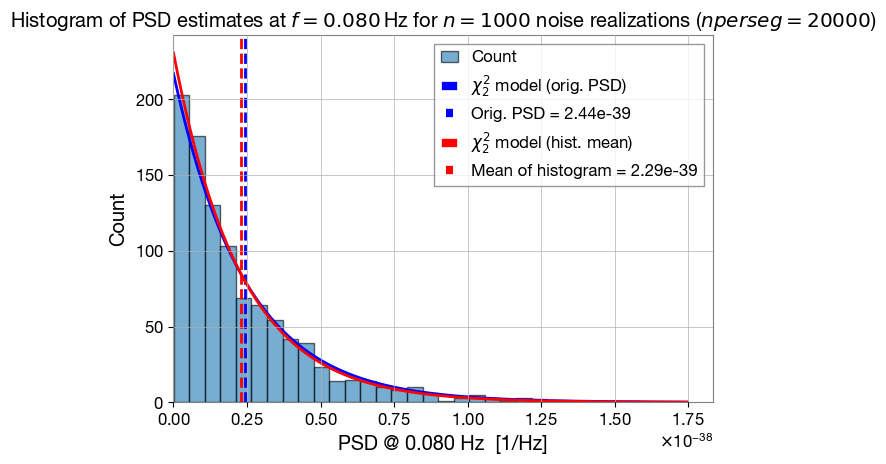

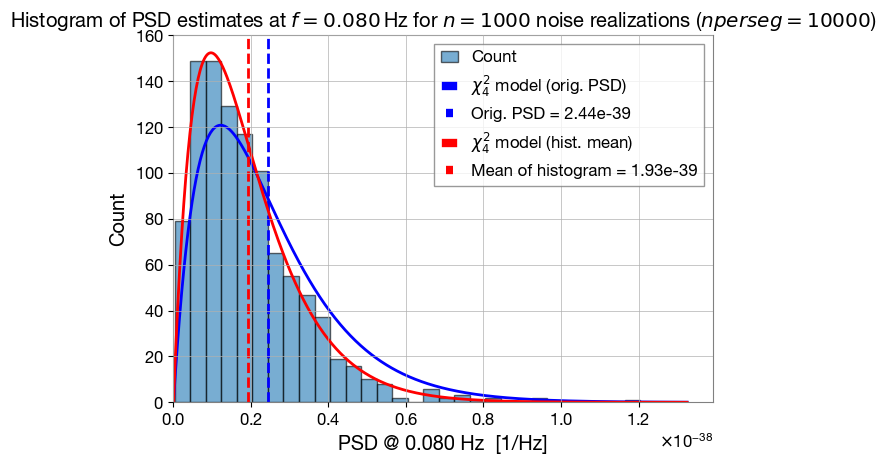

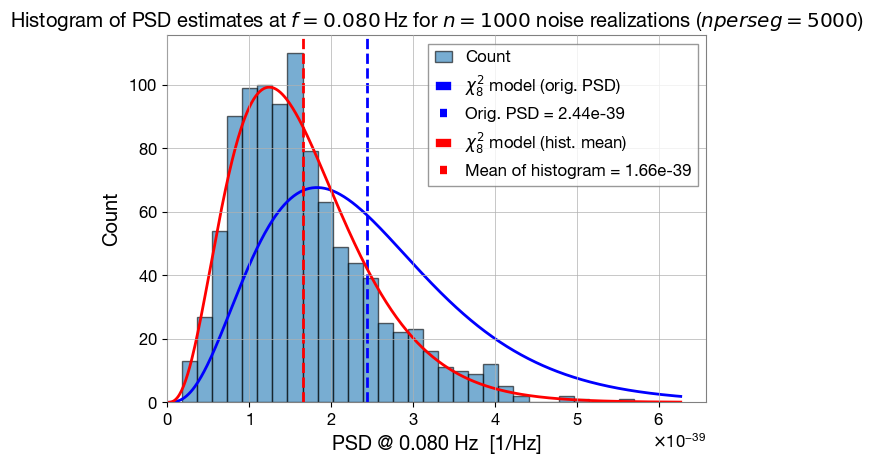

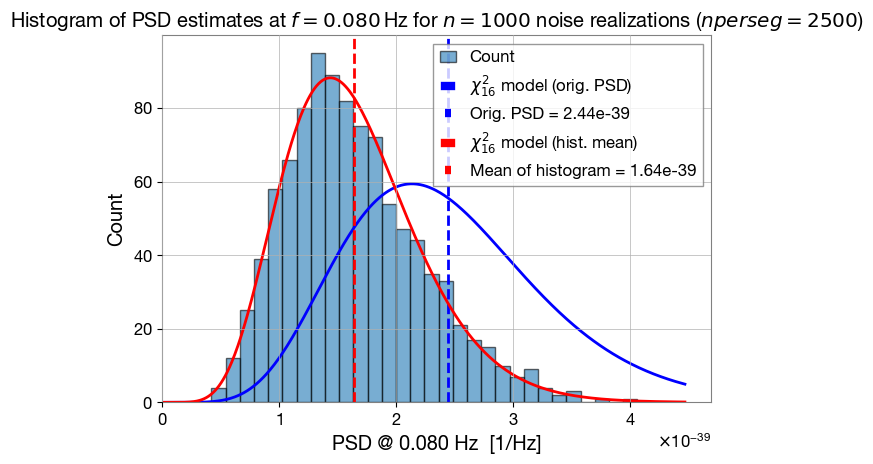

In [23]:
noverlap = 0
fraction = 0.8

nperseg = 20000
f_orig, orig_psd, _, nseg = wosa(
    x=data_orig,
    fs=fs,
    nperseg=nperseg
) 

nperseg_list = [20_000, 10_000, 5_000, 2_500]

for nperseg_noise in nperseg_list:
    f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap)
    psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(
        orig_psd, f_orig, noise_psds, f_noise, fraction=fraction
    )
    plot_psd_noise_histogram(
        psd_noise_vals,
        orig_psd_val,
        chosen_f_noise,
        df=2*nseg[0],
        n_bins=30,
        title=(
            fr"Histogram of PSD estimates at $f={chosen_f_noise:.3f}\,$Hz "
            fr"for $n={len(psd_noise_vals)}$ noise realizations "
            fr"($nperseg={nperseg_noise}$)"
        )
    )

At 0.07 Hz (the previous diagram was at 0.08 Hz), the bias is smaller:

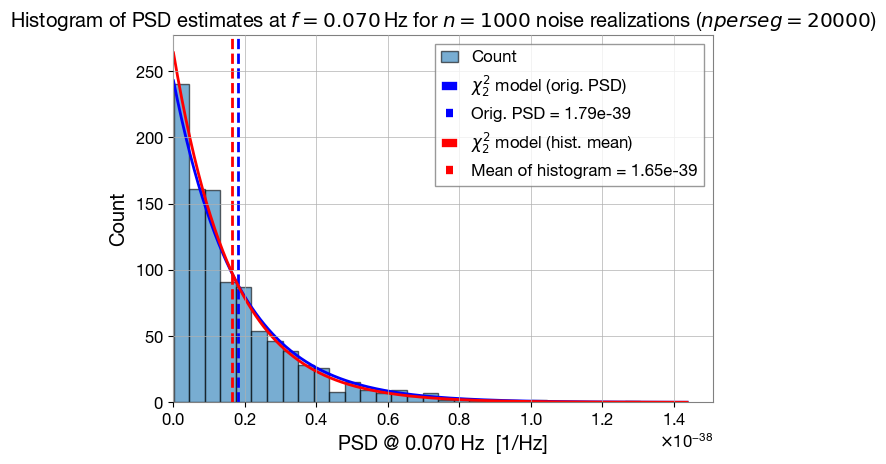

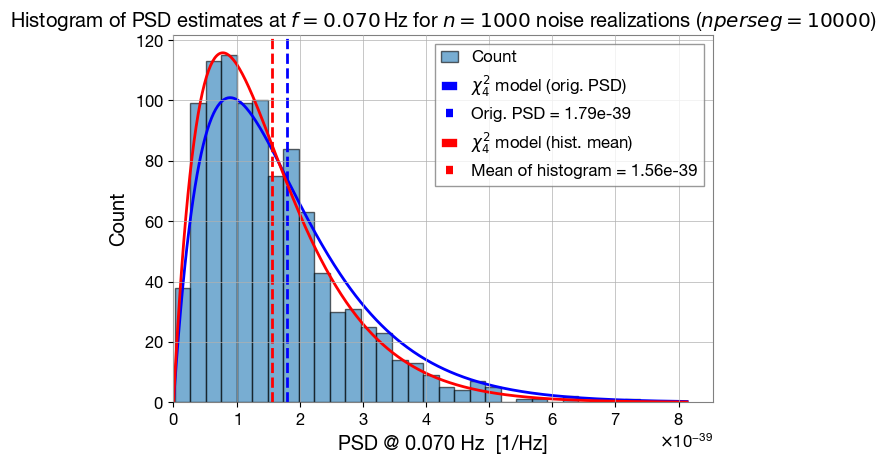

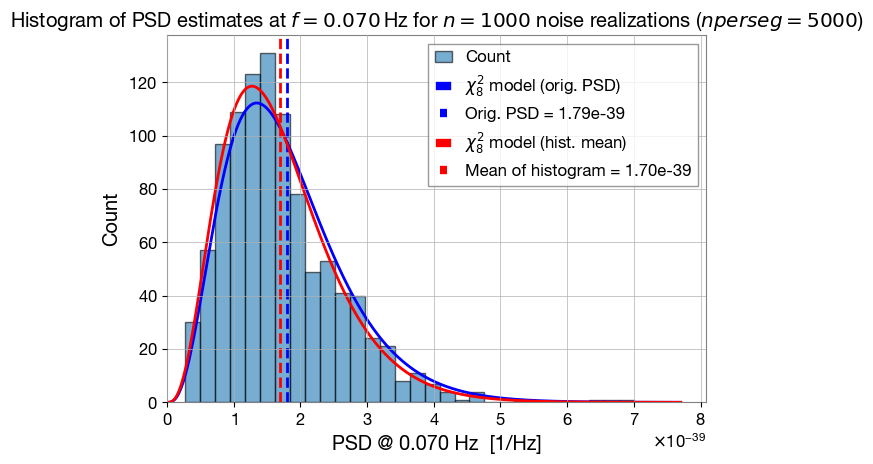

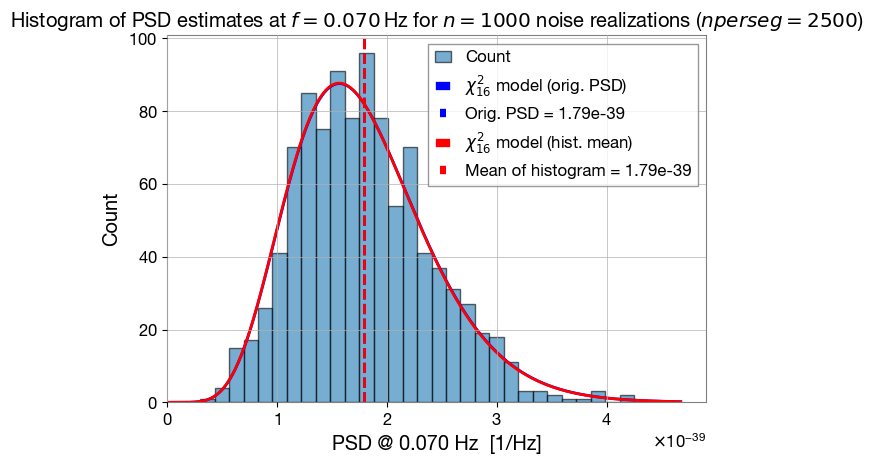

In [24]:
noverlap = 0
fraction = 0.7

nperseg = 20000
f_orig, orig_psd, _, nseg = wosa(
    x=data_orig,
    fs=fs,
    nperseg=nperseg
) 

nperseg_list = [20_000, 10_000, 5_000, 2_500]

for nperseg_noise in nperseg_list:
    f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap)
    psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(
        orig_psd, f_orig, noise_psds, f_noise, fraction=fraction
    )
    plot_psd_noise_histogram(
        psd_noise_vals,
        orig_psd_val,
        chosen_f_noise,
        df=2*nseg[0],
        n_bins=30,
        title=(
            fr"Histogram of PSD estimates at $f={chosen_f_noise:.3f}\,$Hz "
            fr"for $n={len(psd_noise_vals)}$ noise realizations "
            fr"($nperseg={nperseg_noise}$)"
        )
    )

In the following diagram, we see that bias does not grow consistently, and it makes sense. 

- In the previous diagram, we start with a time series, and generate PSD by using a frequency resolution delta_f1. Then, we create noise realisaiotns in time domain, and find the PSD of the noise realisations using frequency resolution delta_f2. When frequency resolutions don't match, the bias is present

- In the following diagram, the noise-realisation PSD and the original-PSD is calculated using the same frequency resolution

chosen f_noise: 0.08
chosen f_orig: 0.08


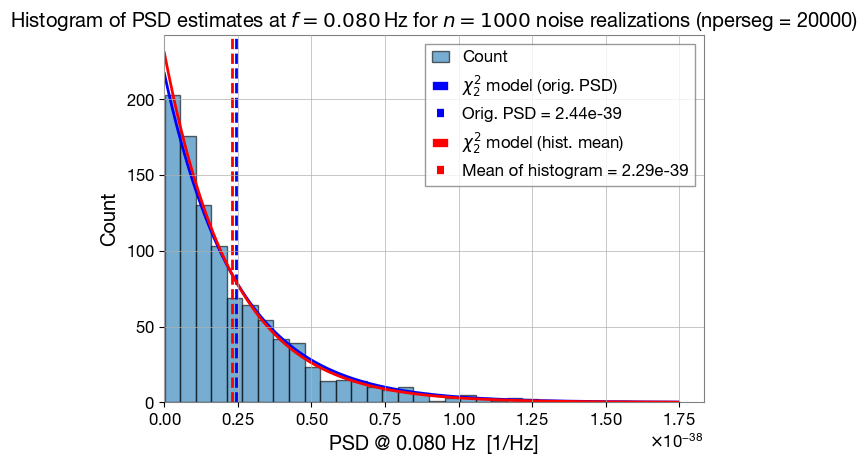

chosen f_noise: 0.08
chosen f_orig: 0.08


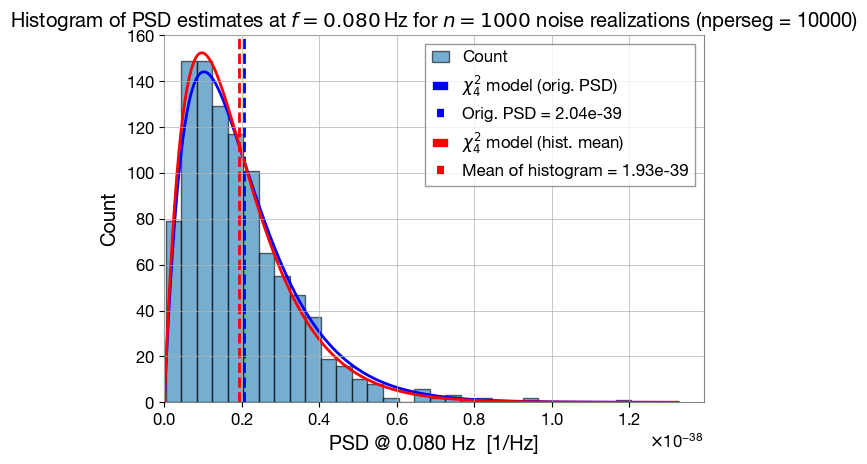

chosen f_noise: 0.08
chosen f_orig: 0.08


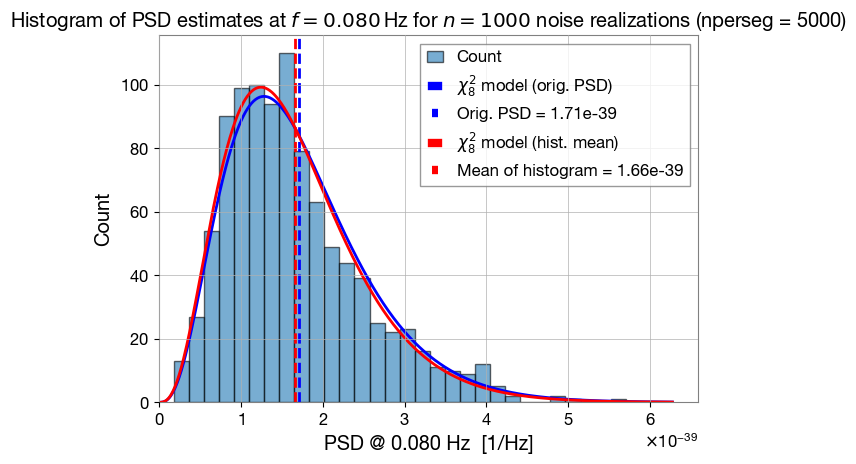

chosen f_noise: 0.08
chosen f_orig: 0.08


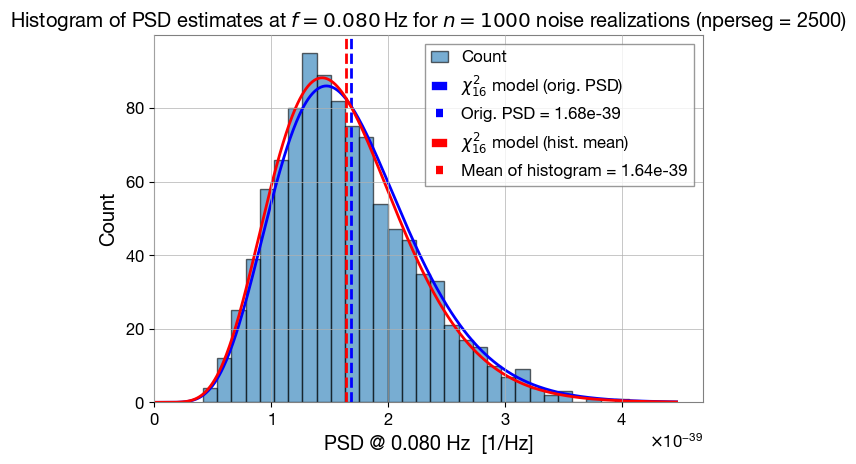

In [9]:
noverlap  = 0
fraction  = 0.8
nperseg_list = [20_000, 10_000, 5_000, 2_500]

for nperseg in nperseg_list:
    f_orig, orig_psd, _, nseg = wosa(
        x=data_orig,
        fs=fs,
        nperseg=nperseg
    )

    # noise-realisation PSDs
    f_noise, noise_psds, nseg = n_noise_psds(
        time_noises, fs, nperseg, noverlap=noverlap
    )

    # pull out the values around the chosen frequency bin
    psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(
        orig_psd, f_orig, noise_psds, f_noise, fraction=fraction
    )

    print(f"chosen f_noise: {chosen_f_noise}")
    print(f"chosen f_orig: {chosen_f_orig}")

    # χ² d.o.f. is 2 × (number of statistically independent segments)
    df = 2 * nseg[0]

    # plot
    plot_psd_noise_histogram(
        psd_noise_vals,
        orig_psd_val,
        chosen_f_noise,
        df=df,
        n_bins=30,
        title=(
            fr"Histogram of PSD estimates at $f={chosen_f_noise:.3f}\,$Hz "
            fr"for $n={len(psd_noise_vals)}$ noise realizations "
            fr"(nperseg = {nperseg})"
        ),
    )

The following dieagram is the same as one of the previous diagram, except its drawn nicely for the report 

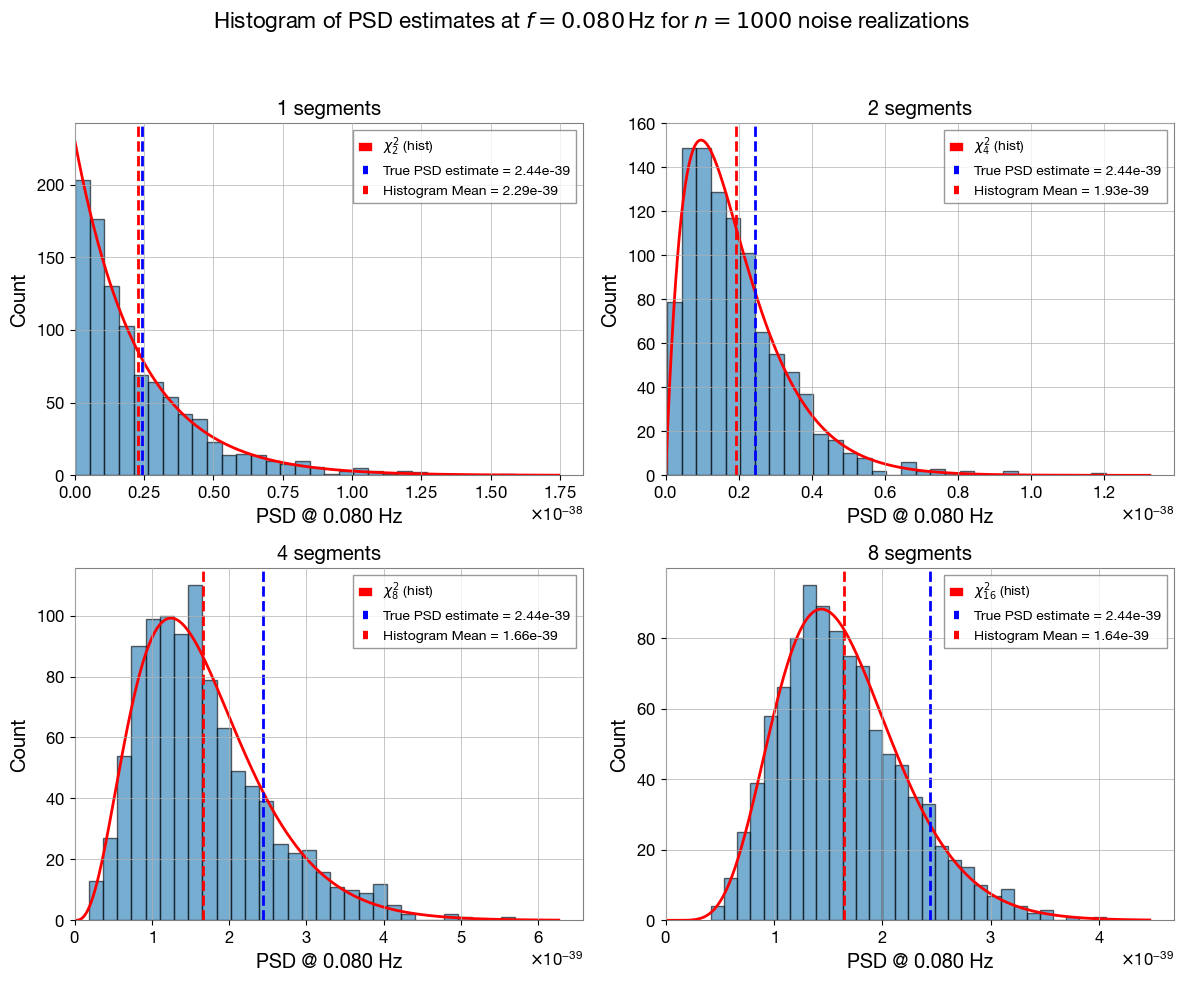

In [12]:
nperseg=20000
f_orig, orig_psd, _, nseg = wosa(
    x=data_orig,
    fs=fs,
    nperseg=nperseg
) 
fraction=0.8
noverlap = 0
# 1) choose your segment-sizes:
nperseg_list = [20000, 10000, 5000, 2500]
noise_vals_list = []
orig_psd_list   = []
freq_list       = []
df_list         = []
seg_counts      = []

for nperseg in nperseg_list:
    f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg, noverlap=noverlap)
    psd_vals, orig_val, chosen_freq, _ = compute_psd_noise_distribution(
        orig_psd, f_orig, noise_psds, f_noise, fraction=fraction
    )
    noise_vals_list.append(psd_vals)
    orig_psd_list.append(orig_val)
    freq_list.append(chosen_freq)
    df_list.append(2 * nseg[0])
    seg_counts.append(nseg[0])

main_title = (
    fr"Histogram of PSD estimates at $f={chosen_freq:.3f}\,$Hz "
    fr"for $n={len(noise_vals_list[0])}$ noise realizations"
)

plot_psd_noise_histogram_two_cross_two(
    noise_vals_list,
    orig_psd_list,
    freq_list,
    df_list,
    seg_counts,
    main_title,
    n_bins=30,
    show_biased_hist=False
)


At lower frequqnecy, the nois-realisations-PSD lie above the original PSD, and thats why the diagram below looks weird. Theres an order of 2 difference between histogram-mean and original PSD

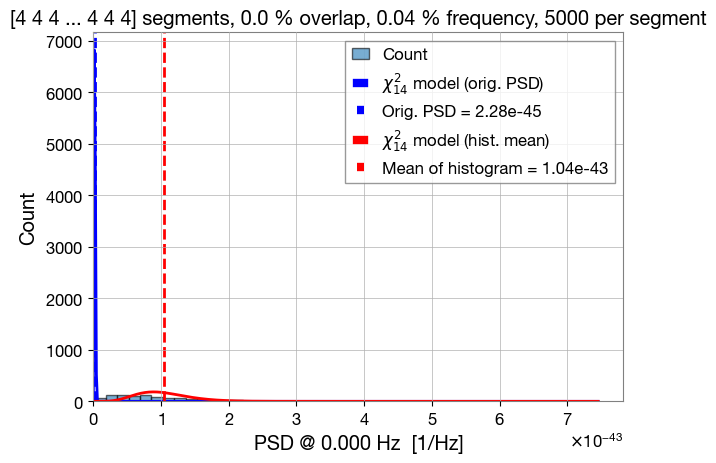

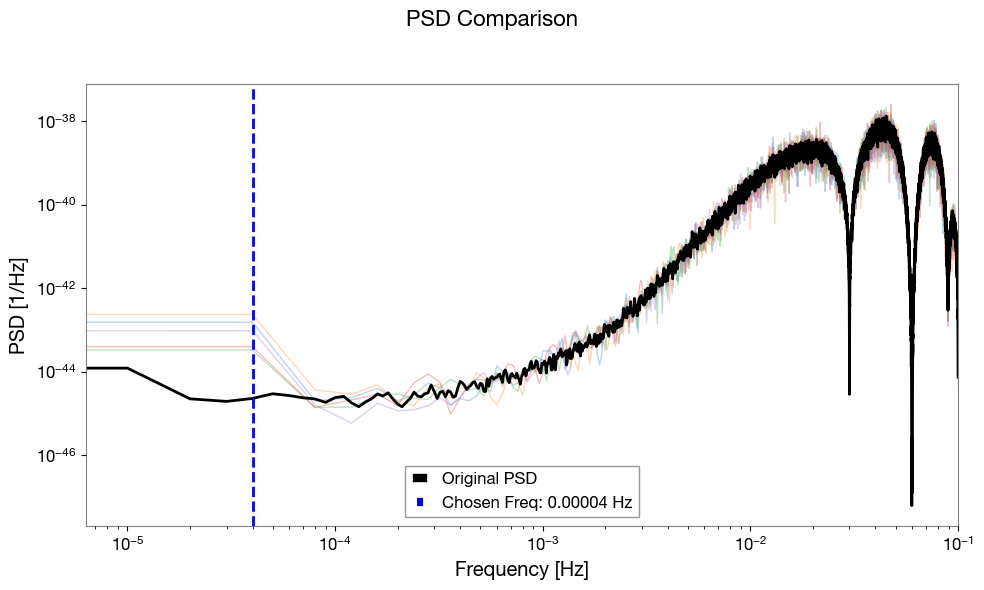

In [27]:
nperseg_noise = 5000
noverlap = 0
fraction = 0.0004
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap)
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)
plot_psd_noise_histogram(psd_noise_vals, orig_psd_val, chosen_f_noise, title=f"{nseg} segments, {noverlap / nperseg_noise * 100} % overlap, {fraction * 100} % frequency, {nperseg_noise} per segment", 
    n_bins=40,  
    df=14
)

plot_orig_and_noise_psds(f_orig, orig_psd, chosen_f_orig, f_noise, noise_psds, chosen_f_noise, n=5, alpha=0.3, bigtitle="PSD Comparison")

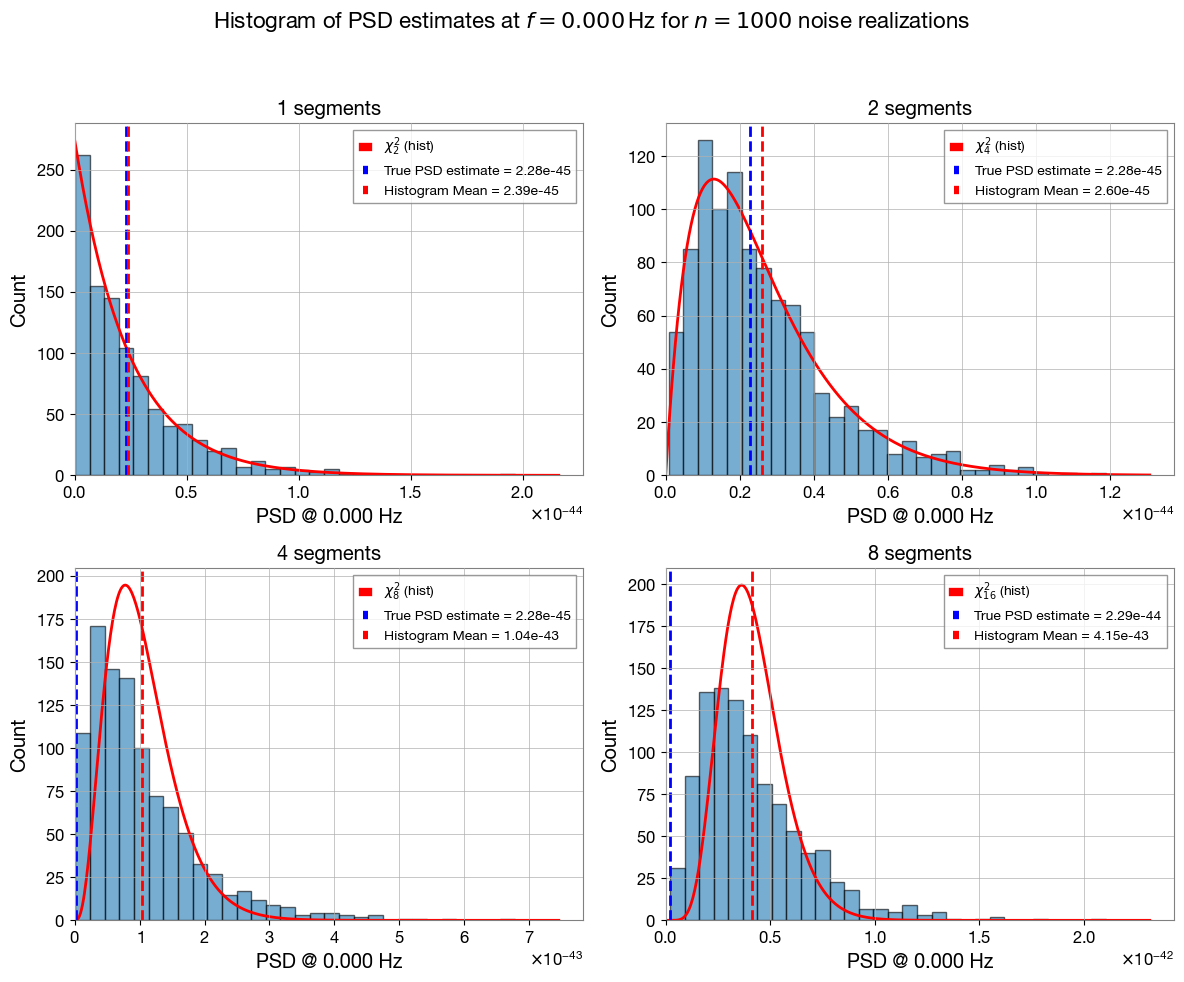

/Users/akmdgreat/anaconda3/envs/bethenv/lib/python3.11/site-packages/gwpy/plot/axes.py:78: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  return func(self, **kw)


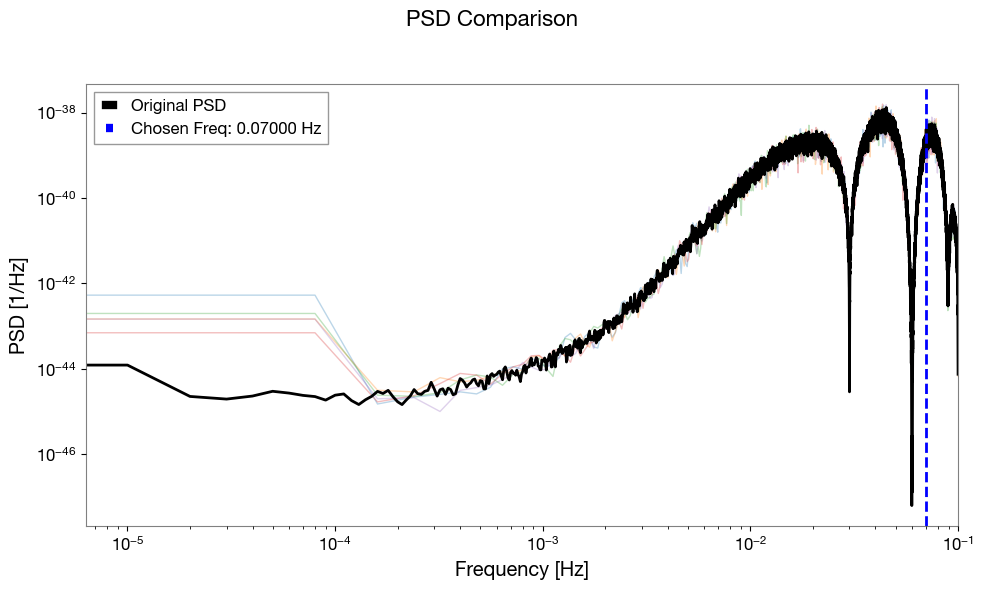

In [26]:
nperseg=20000
f_orig, orig_psd, _, nseg = wosa(
    x=data_orig,
    fs=fs,
    nperseg=nperseg
) 
fraction=0.0004
noverlap = 0
# 1) choose your segment-sizes:
nperseg_list = [20000, 10000, 5000, 2500]
noise_vals_list = []
orig_psd_list   = []
freq_list       = []
df_list         = []
seg_counts      = []

for nperseg in nperseg_list:
    f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg, noverlap=noverlap)
    psd_vals, orig_val, chosen_freq, _ = compute_psd_noise_distribution(
        orig_psd, f_orig, noise_psds, f_noise, fraction=fraction
    )
    noise_vals_list.append(psd_vals)
    orig_psd_list.append(orig_val)
    freq_list.append(chosen_freq)
    df_list.append(2 * nseg[0])
    seg_counts.append(nseg[0])

main_title = (
    fr"Histogram of PSD estimates at $f={chosen_freq:.3f}\,$Hz "
    fr"for $n={len(noise_vals_list[0])}$ noise realizations"
)

plot_psd_noise_histogram_two_cross_two(
    noise_vals_list,
    orig_psd_list,
    freq_list,
    df_list,
    seg_counts,
    main_title,
    n_bins=30,
    show_biased_hist=False
)

plot_orig_and_noise_psds(f_orig, orig_psd, chosen_f_orig, f_noise, noise_psds, chosen_f_noise, n=5, alpha=0.3, bigtitle="PSD Comparison")
